In [32]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [33]:
df = pd.read_csv('datauber.csv')
df.head(10)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.00000061,12.9,NaN,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0
5,44470845.0,2011-02-12 02:27:09.0000006,4.9,2011-02-12 02:27:09 UTC,-73.969019,40.755910,-73.969019,40.755910,1.0
6,48725865.0,2014-10-12 07:04:00.0000002,24.5,2014-10-12 07:04:00 UTC,NaN,40.693965,-73.871195,40.774297,5.0
7,44195482.0,2012-12-11 13:52:00.00000029,2.5,2012-12-11 13:52:00 UTC,0.000000,0.000000,0.000000,0.000000,1.0
8,15822268.0,2012-02-17 09:32:00.00000043,9.7,2012-02-17 09:32:00 UTC,-73.975187,40.745767,-74.002720,40.743537,1.0
9,50611056.0,2012-03-29 19:06:00.000000273,12.5,2012-03-29 19:06:00 UTC,-74.001065,40.741787,-73.963040,NaN,1.0


In [34]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44377 entries, 0 to 44376
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         42243 non-null  float64
 1   key                42143 non-null  object 
 2   fare_amount        42217 non-null  float64
 3   pickup_datetime    42094 non-null  object 
 4   pickup_longitude   42183 non-null  float64
 5   pickup_latitude    42130 non-null  float64
 6   dropoff_longitude  42183 non-null  float64
 7   dropoff_latitude   42119 non-null  float64
 8   passenger_count    42159 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.0+ MB


In [36]:
df = df.drop(columns=['Unnamed: 0', 'key', 'fare_amount', 
                      'dropoff_longitude', 'dropoff_latitude', 
                      'passenger_count'])

In [37]:
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude
0,2015-05-07 19:52:06 UTC,-73.999817,40.738354
1,2009-07-17 20:04:56 UTC,-73.994355,40.728225
2,NaN,-74.005043,40.740770
3,2009-06-26 08:22:21 UTC,-73.976124,NaN
4,2014-08-28 17:47:00 UTC,NaN,40.744085


In [38]:
# Supprimer les lignes où pickup_datetime est NaN
df = df.dropna(subset=['pickup_datetime'])
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude
0,2015-05-07 19:52:06 UTC,-73.999817,40.738354
1,2009-07-17 20:04:56 UTC,-73.994355,40.728225
3,2009-06-26 08:22:21 UTC,-73.976124,NaN
4,2014-08-28 17:47:00 UTC,NaN,40.744085
5,2011-02-12 02:27:09 UTC,-73.969019,40.755910


In [39]:
# Convertir la colonne pickup_datetime en format datetime (UTC compris)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude
0,2015-05-07 19:52:06+00:00,-73.999817,40.738354
1,2009-07-17 20:04:56+00:00,-73.994355,40.728225
3,2009-06-26 08:22:21+00:00,-73.976124,NaN
4,2014-08-28 17:47:00+00:00,NaN,40.744085
5,2011-02-12 02:27:09+00:00,-73.969019,40.755910


In [40]:
df['hour']= df['pickup_datetime'].dt.hour
df['day']= df['pickup_datetime'].dt.day
df['month']= df['pickup_datetime'].dt.month
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['month'].apply(get_season)


In [41]:
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude,hour,day,month,season
0,2015-05-07 19:52:06+00:00,-73.999817,40.738354,19,7,5,spring
1,2009-07-17 20:04:56+00:00,-73.994355,40.728225,20,17,7,summer
3,2009-06-26 08:22:21+00:00,-73.976124,NaN,8,26,6,summer
4,2014-08-28 17:47:00+00:00,NaN,40.744085,17,28,8,summer
5,2011-02-12 02:27:09+00:00,-73.969019,40.755910,2,12,2,winter


In [42]:
df.drop(columns=['pickup_datetime'], inplace=True)

In [43]:
df.head()

,pickup_longitude,pickup_latitude,hour,day,month,season
0,-73.999817,40.738354,19,7,5,spring
1,-73.994355,40.728225,20,17,7,summer
3,-73.976124,NaN,8,26,6,summer
4,NaN,40.744085,17,28,8,summer
5,-73.969019,40.755910,2,12,2,winter


In [44]:
df = df.dropna(subset=['pickup_longitude', 'pickup_latitude'])

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37958 entries, 0 to 44376
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  37958 non-null  float64
 1   pickup_latitude   37958 non-null  float64
 2   hour              37958 non-null  int32  
 3   day               37958 non-null  int32  
 4   month             37958 non-null  int32  
 5   season            37958 non-null  object 
dtypes: float64(2), int32(3), object(1)
memory usage: 1.6+ MB


In [46]:
df.head()

,pickup_longitude,pickup_latitude,hour,day,month,season
0,-73.999817,40.738354,19,7,5,spring
1,-73.994355,40.728225,20,17,7,summer
5,-73.969019,40.755910,2,12,2,winter
7,0.000000,0.000000,13,11,12,winter
8,-73.975187,40.745767,9,17,2,winter


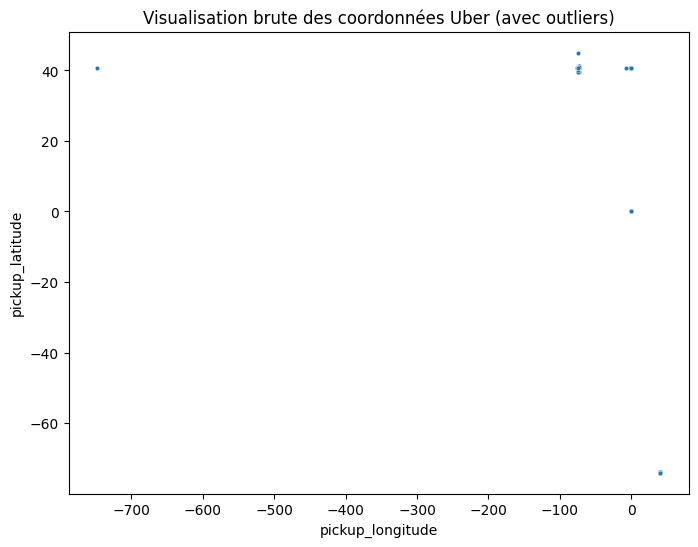

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.title("Visualisation brute des coordonnées Uber (avec outliers)")
plt.show()


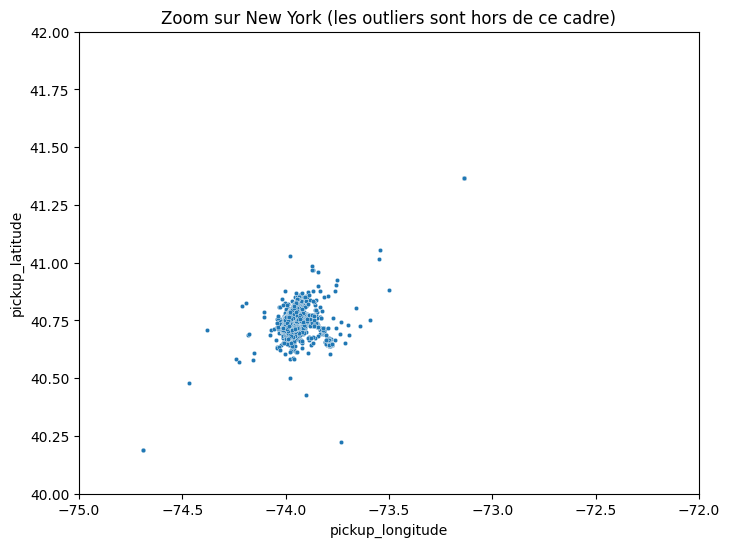

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.xlim(-75, -72)   # limites longitude New York
plt.ylim(40, 42)     # limites latitude New York
plt.title("Zoom sur New York (les outliers sont hors de ce cadre)")
plt.show()


In [49]:
df = df[
    (df['pickup_longitude'] > -75) & (df['pickup_longitude'] < -72) &
    (df['pickup_latitude'] > 40) & (df['pickup_latitude'] < 42)
]


In [50]:
df[
    (df['pickup_longitude'] < -75) | (df['pickup_longitude'] > -72) &
    (df['pickup_latitude'] < 40) | (df['pickup_latitude'] > 42)
].head()


,pickup_longitude,pickup_latitude,hour,day,month,season


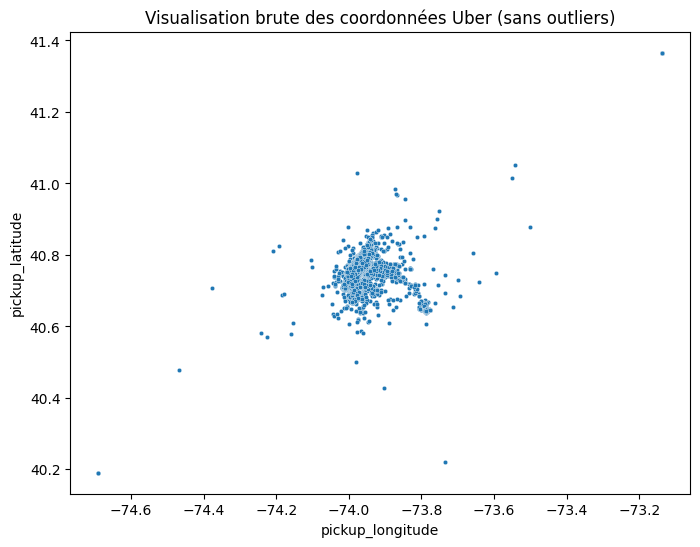

In [51]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.title("Visualisation brute des coordonnées Uber (sans outliers)")
plt.show()


In [52]:
df=df[df["pickup_longitude"]<-73.2]


In [53]:
# Vérifier s'il y a des lignes entièrement dupliquées
print("Nombre de lignes dupliquées :", df.duplicated().sum())

# Afficher les lignes dupliquées (s'il y en a)
duplicated_rows = df[df.duplicated()]
print("Lignes dupliquées :", duplicated_rows)

# Vérifier les doublons en gardant seulement la première occurrence
print("Total des doublons (sans la première occurrence) :", df.duplicated(keep='first').sum())

# Vérifier les doublons sur des colonnes spécifiques (par exemple longitude et latitude)
print("Doublons sur coordonnées :", df.duplicated(subset=['pickup_longitude', 'pickup_latitude']).sum())

Nombre de lignes dupliquées : 81
Lignes dupliquées :        pickup_longitude  pickup_latitude  hour  day  month  season
44272        -73.985667        40.756045    21   20      6  summer
44273        -73.922888        40.798345     1   20      3  spring
44275        -73.951439        40.771996    17   28      1  winter
44276        -73.995147        40.739425    18   12     11  autumn
44277        -73.991655        40.726787    22   20     12  winter
...                 ...              ...   ...  ...    ...     ...
44372        -73.989875        40.719197     1   28      9  autumn
44373        -73.994805        40.740033    19   28      3  spring
44374        -73.982996        40.726833    12   30      3  spring
44375        -73.958802        40.810530    22    7     11  autumn
44376        -73.982371        40.765501     0   12      7  summer

[81 rows x 6 columns]
Total des doublons (sans la première occurrence) : 81
Doublons sur coordonnées : 92


In [54]:
from sklearn.cluster import DBSCAN

In [55]:


# Version corrigée pour la géographie
coords_rad = np.radians(df[['pickup_latitude','pickup_longitude']].values)
eps_m = 300  # 200 mètres de rayon
eps_rad = eps_m / 6_371_000
db = DBSCAN(eps=eps_rad, min_samples=10, metric='haversine').fit(coords_rad)
df['cluster'] = db.labels_

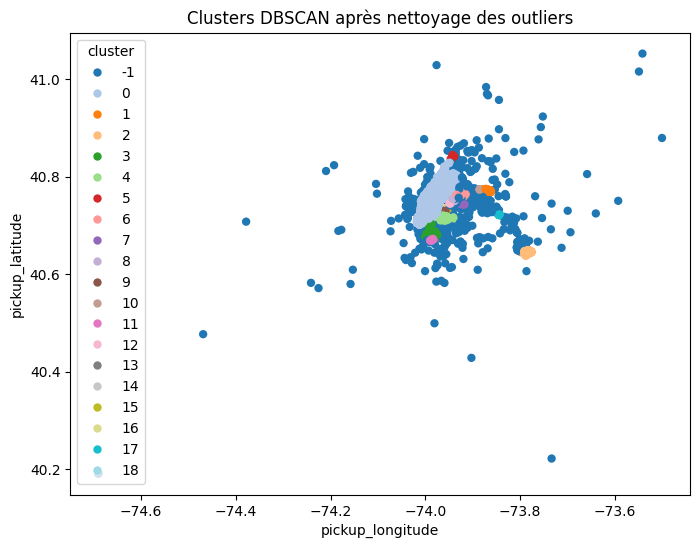

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude',
                hue='cluster', palette='tab20', linewidth=0)
plt.title("Clusters DBSCAN après nettoyage des outliers")
plt.show()


In [57]:
# Regardons 2 zones différentes dans tes données
# Zone dense (Manhattan centre)
manhattan = df[(df['pickup_longitude'] > -74.0) & (df['pickup_longitude'] < -73.95)]
print(f"Manhattan : {len(manhattan)} courses dans un petit carré")

# Zone moins dense (extérieur)
exterieur = df[df['pickup_longitude'] < -74.1]  
print(f"Extérieur : {len(exterieur)} courses dans un grand carré")

Manhattan : 29157 courses dans un petit carré
Extérieur : 15 courses dans un grand carré


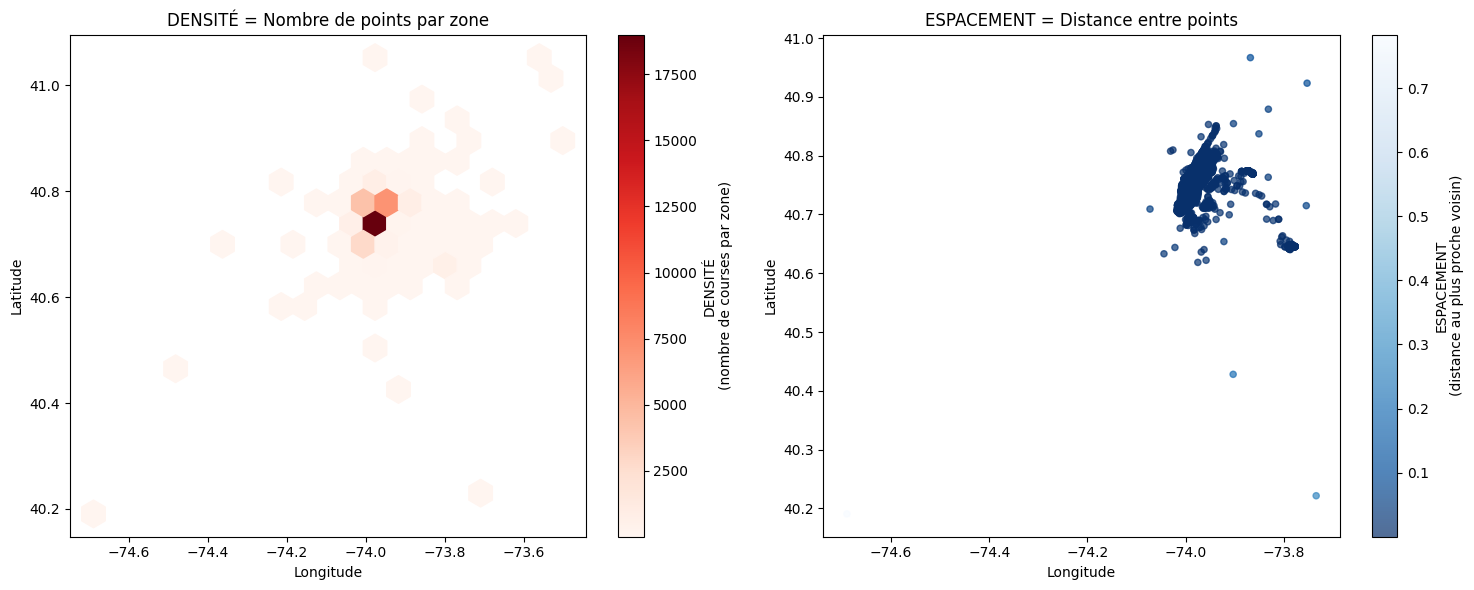

In [58]:
# Calculer la densité explicitement
from scipy.spatial.distance import pdist
import matplotlib.patches as patches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Heatmap de densité (nombre de points par zone)
im = ax1.hexbin(df['pickup_longitude'], df['pickup_latitude'], 
                gridsize=20, cmap='Reds', mincnt=1)
plt.colorbar(im, ax=ax1, label='DENSITÉ\n(nombre de courses par zone)')
ax1.set_title("DENSITÉ = Nombre de points par zone")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# 2. Exemple d'espacement (distance moyenne au plus proche voisin)
from sklearn.neighbors import NearestNeighbors
coords = df[['pickup_longitude', 'pickup_latitude']].values[:5000]  # échantillon
nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
distances, _ = nbrs.kneighbors(coords)
avg_spacing = distances[:, 1]  # distance au 1er voisin

scatter = ax2.scatter(coords[:, 0], coords[:, 1], 
                     c=avg_spacing, cmap='Blues_r', s=20, alpha=0.7)
plt.colorbar(scatter, ax=ax2, label='ESPACEMENT\n(distance au plus proche voisin)')
ax2.set_title("ESPACEMENT = Distance entre points")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [59]:
df[df['cluster'] == 29].info()


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  0 non-null      float64
 1   pickup_latitude   0 non-null      float64
 2   hour              0 non-null      int32  
 3   day               0 non-null      int32  
 4   month             0 non-null      int32  
 5   season            0 non-null      object 
 6   cluster           0 non-null      int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 0.0+ bytes


In [60]:
df[df['cluster'] == 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 34273 entries, 0 to 44376
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  34273 non-null  float64
 1   pickup_latitude   34273 non-null  float64
 2   hour              34273 non-null  int32  
 3   day               34273 non-null  int32  
 4   month             34273 non-null  int32  
 5   season            34273 non-null  object 
 6   cluster           34273 non-null  int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 1.7+ MB


In [61]:
import hdbscan

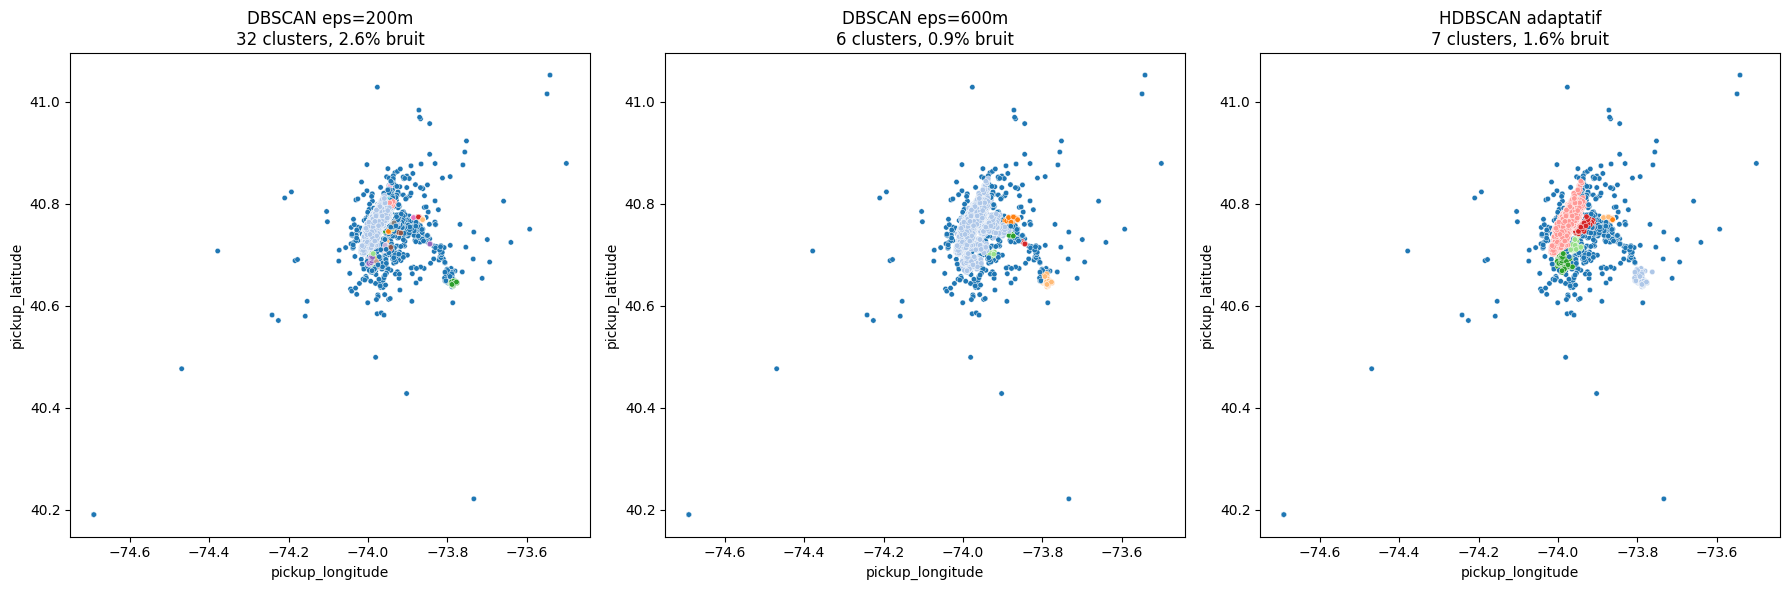

In [62]:
# Comparaison côte à côte sur tes données
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

coords_rad = np.radians(df[['pickup_latitude','pickup_longitude']].values)

# 1. DBSCAN eps petit (adapté centre-ville)
eps_small = 200 / 6_371_000
db_small = DBSCAN(eps=eps_small, min_samples=10, metric='haversine')
labels_small = db_small.fit_predict(coords_rad)

# 2. DBSCAN eps grand (adapté banlieue)
eps_large = 600 / 6_371_000  
db_large = DBSCAN(eps=eps_large, min_samples=10, metric='haversine')
labels_large = db_large.fit_predict(coords_rad)

# 3. HDBSCAN adaptatif
hdb = hdbscan.HDBSCAN(min_cluster_size=150, min_samples=10, metric='haversine')
labels_hdb = hdb.fit_predict(coords_rad)

# Visualisation
for ax, labels, title in zip([ax1, ax2, ax3], 
                           [labels_small, labels_large, labels_hdb],
                           ["DBSCAN eps=200m", "DBSCAN eps=600m", "HDBSCAN adaptatif"]):
    df_temp = df.copy()
    df_temp['cluster'] = labels
    
    sns.scatterplot(data=df_temp, x='pickup_longitude', y='pickup_latitude',
                    hue='cluster', palette='tab20', s=15, ax=ax, legend=False)
    ax.set_title(f"{title}\n{len(set(labels))-1} clusters, {(labels==-1).mean():.1%} bruit")

plt.tight_layout()
plt.show()

In [63]:
df = df[df["cluster"] != -1]

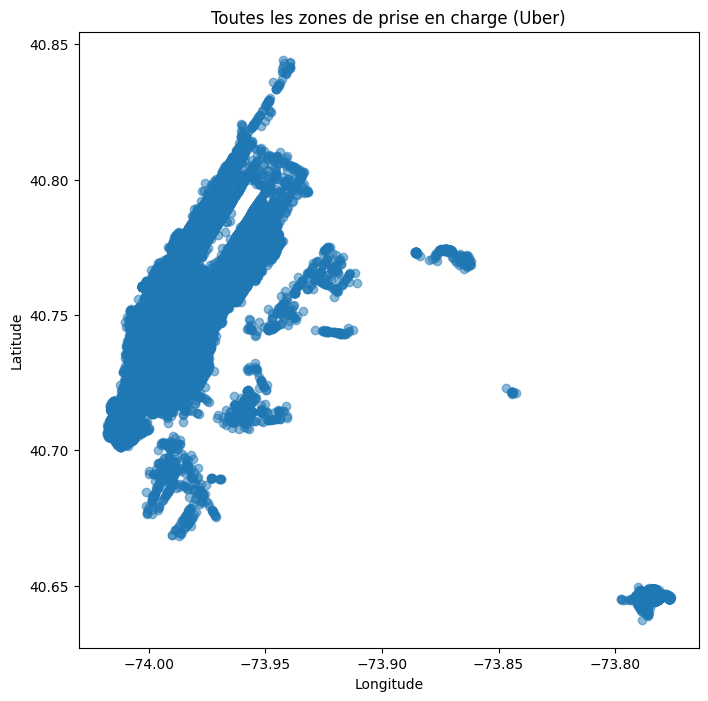

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(df['pickup_longitude'], df['pickup_latitude'], alpha=0.5)
plt.title("Toutes les zones de prise en charge (Uber)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


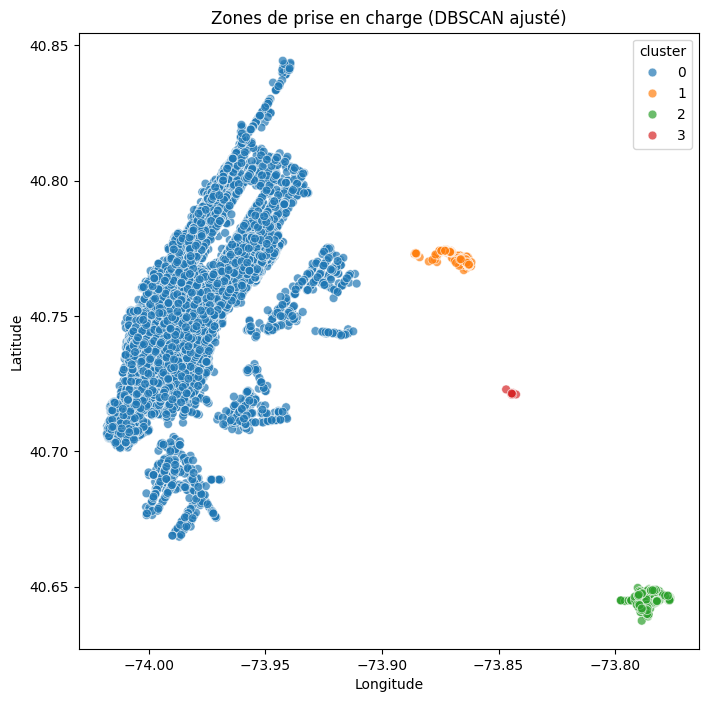

In [65]:


# DBSCAN avec paramètres ajustés
dbscan = DBSCAN(eps=0.01, min_samples=10, metric='euclidean')
df['cluster'] = dbscan.fit_predict(df[['pickup_longitude', 'pickup_latitude']])

# Visualisation
plt.figure(figsize=(8,8))
sns.scatterplot(
    x='pickup_longitude', 
    y='pickup_latitude',
    hue='cluster',
    palette='tab10',
    data=df,
    legend='full',
    s=40,
    alpha=0.7
)
plt.title("Zones de prise en charge (DBSCAN ajusté)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [66]:
df.head()

,pickup_longitude,pickup_latitude,hour,day,month,season,cluster
0,-73.999817,40.738354,19,7,5,spring,0
1,-73.994355,40.728225,20,17,7,summer,0
5,-73.969019,40.755910,2,12,2,winter,0
8,-73.975187,40.745767,9,17,2,winter,0
9,-74.001065,40.741787,19,29,3,spring,0


In [67]:
df[df['cluster'] == 1].info()

<class 'pandas.core.frame.DataFrame'>
Index: 771 entries, 104 to 44295
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  771 non-null    float64
 1   pickup_latitude   771 non-null    float64
 2   hour              771 non-null    int32  
 3   day               771 non-null    int32  
 4   month             771 non-null    int32  
 5   season            771 non-null    object 
 6   cluster           771 non-null    int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 39.2+ KB


In [68]:
df[df['cluster'] == 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 35231 entries, 0 to 44376
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  35231 non-null  float64
 1   pickup_latitude   35231 non-null  float64
 2   hour              35231 non-null  int32  
 3   day               35231 non-null  int32  
 4   month             35231 non-null  int32  
 5   season            35231 non-null  object 
 6   cluster           35231 non-null  int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 1.7+ MB


In [69]:
df[df['cluster'] == -1].info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  0 non-null      float64
 1   pickup_latitude   0 non-null      float64
 2   hour              0 non-null      int32  
 3   day               0 non-null      int32  
 4   month             0 non-null      int32  
 5   season            0 non-null      object 
 6   cluster           0 non-null      int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 0.0+ bytes


In [70]:
df=df[df['cluster'] != -1]

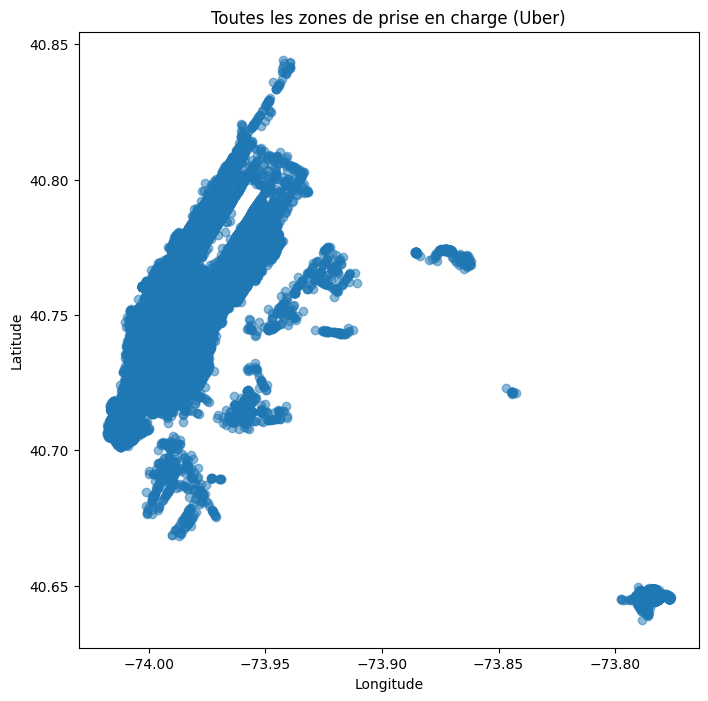

In [71]:
plt.figure(figsize=(8,8))
plt.scatter(df['pickup_longitude'], df['pickup_latitude'], alpha=0.5)
plt.title("Toutes les zones de prise en charge (Uber)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

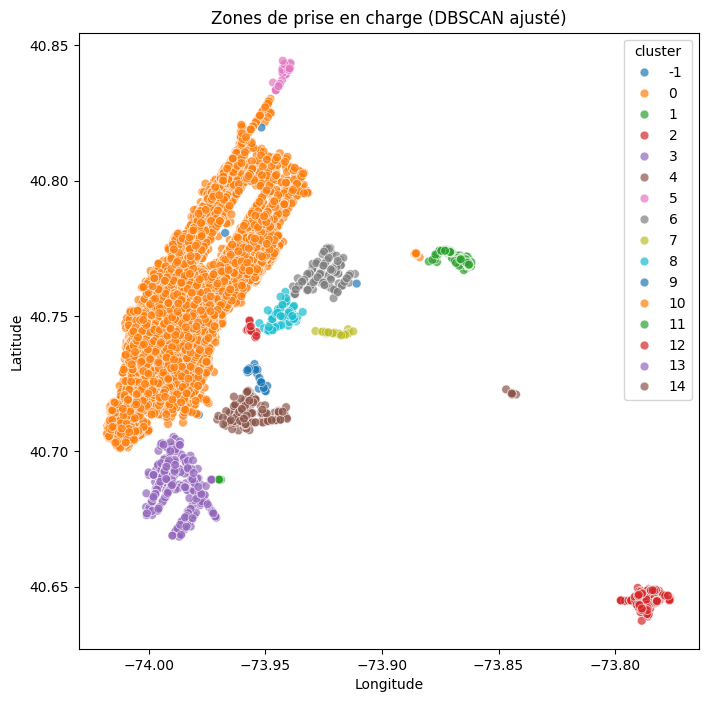

In [72]:
# DBSCAN avec paramètres ajustés
dbscan = DBSCAN(eps=0.003, min_samples=5, metric='euclidean')
df['cluster'] = dbscan.fit_predict(df[['pickup_longitude', 'pickup_latitude']])

# Visualisation
plt.figure(figsize=(8,8))
sns.scatterplot(
    x='pickup_longitude', 
    y='pickup_latitude',
    hue='cluster',
    palette='tab10',
    data=df,
    legend='full',
    s=40,
    alpha=0.7
)
plt.title("Zones de prise en charge (DBSCAN ajusté)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [73]:
for i in range(0,8):
    df[df['cluster'] == i].info()

<class 'pandas.core.frame.DataFrame'>
Index: 34270 entries, 0 to 44376
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  34270 non-null  float64
 1   pickup_latitude   34270 non-null  float64
 2   hour              34270 non-null  int32  
 3   day               34270 non-null  int32  
 4   month             34270 non-null  int32  
 5   season            34270 non-null  object 
 6   cluster           34270 non-null  int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 104 to 44295
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  729 non-null    float64
 1   pickup_latitude   729 non-null    float64
 2   hour              729 non-null    int32  
 3   day               729 non-null    int32  
 4   month       

In [74]:
df[df['cluster'] == -1].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 10568 to 40319
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  4 non-null      float64
 1   pickup_latitude   4 non-null      float64
 2   hour              4 non-null      int32  
 3   day               4 non-null      int32  
 4   month             4 non-null      int32  
 5   season            4 non-null      object 
 6   cluster           4 non-null      int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 208.0+ bytes


In [75]:


coords_rad = np.radians(df[['pickup_latitude','pickup_longitude']].values)
hdb = hdbscan.HDBSCAN(min_cluster_size=150, min_samples=5, metric='haversine')
df['cluster'] = hdb.fit_predict(coords_rad)

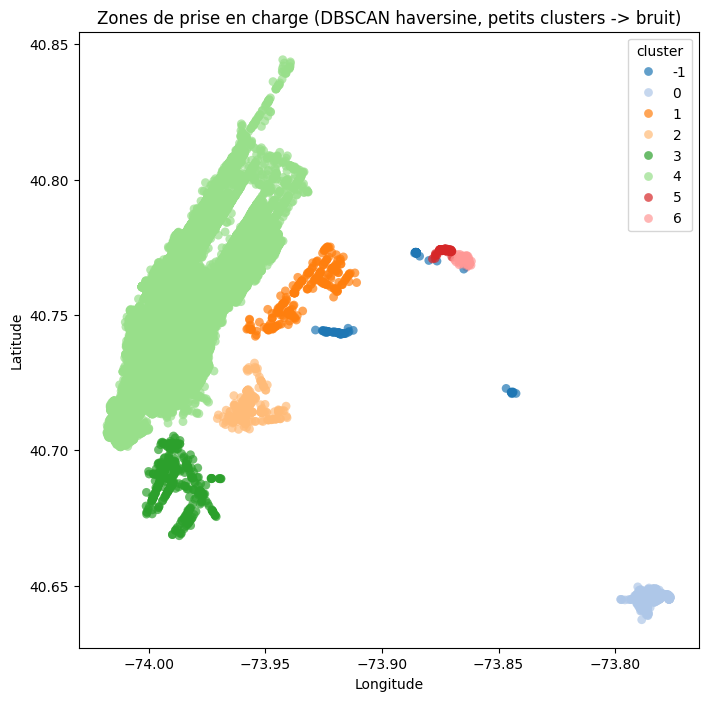

In [76]:
plt.figure(figsize=(8,8))
sns.scatterplot(
    data=df, x='pickup_longitude', y='pickup_latitude',
    hue='cluster', palette='tab20', s=40, alpha=0.7, linewidth=0
)
plt.title("Zones de prise en charge (DBSCAN haversine, petits clusters -> bruit)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(title="cluster")
plt.show()

In [77]:
df[df['cluster'] == -1].info()

<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, 496 to 44168
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  108 non-null    float64
 1   pickup_latitude   108 non-null    float64
 2   hour              108 non-null    int32  
 3   day               108 non-null    int32  
 4   month             108 non-null    int32  
 5   season            108 non-null    object 
 6   cluster           108 non-null    int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 5.5+ KB


In [78]:
df=df[df['cluster'] != -1]

In [79]:

coords_rad = np.radians(df[['pickup_latitude','pickup_longitude']].values)
hdb = hdbscan.HDBSCAN(min_cluster_size=150, min_samples=5, metric='haversine')
df['cluster'] = hdb.fit_predict(coords_rad)


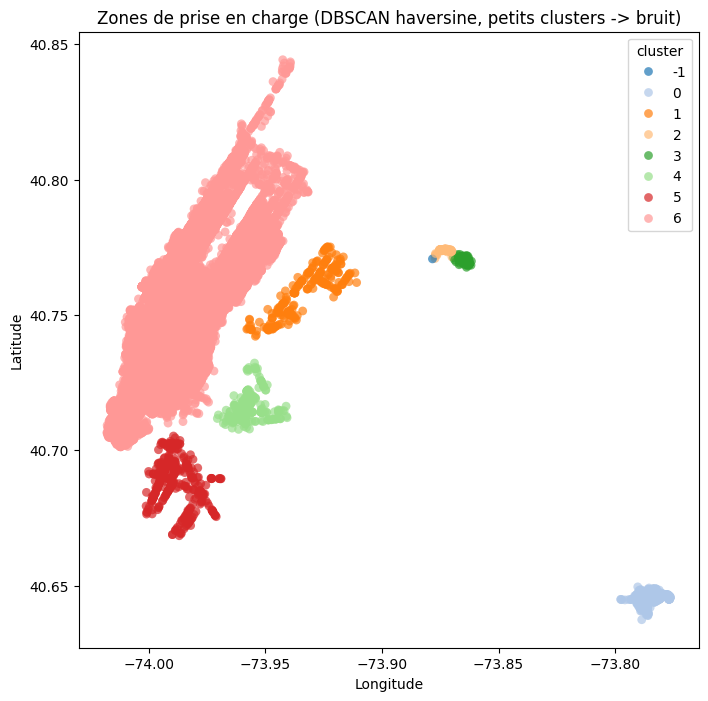

In [80]:
plt.figure(figsize=(8,8))
sns.scatterplot(
    data=df, x='pickup_longitude', y='pickup_latitude',
    hue='cluster', palette='tab20', s=40, alpha=0.7, linewidth=0
)
plt.title("Zones de prise en charge (DBSCAN haversine, petits clusters -> bruit)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(title="cluster")
plt.show()

In [81]:
df[df['cluster'] == 5].info()

<class 'pandas.core.frame.DataFrame'>
Index: 370 entries, 149 to 44324
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  370 non-null    float64
 1   pickup_latitude   370 non-null    float64
 2   hour              370 non-null    int32  
 3   day               370 non-null    int32  
 4   month             370 non-null    int32  
 5   season            370 non-null    object 
 6   cluster           370 non-null    int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 18.8+ KB
